In [3]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

possible_files = [
    "Titanic.csv",
    "/mnt/data/Titanic.csv",
    "/content/Titanic.csv"
]

file_path = next((file for file in possible_files if os.path.exists(file)), None)

if file_path is None:
    print("Dataset file not found.")
else:
    df = pd.read_csv(file_path)
    print("Dataset loaded successfully.")
    print("File path:", file_path)

Dataset loaded successfully.
File path: Titanic.csv


In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.describe(include="all")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [7]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [8]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df["Cabin"] = df["Cabin"].fillna("Unknown")

df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


Q1. Create a countplot to show the number of passengers by gender.

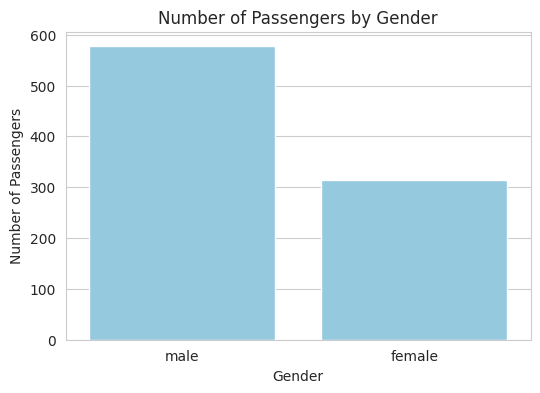

,count
Sex,
male,577
female,314


In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x="Sex", data=df, color="skyblue")
plt.title("Number of Passengers by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.show()

df["Sex"].value_counts()

Interpretation: Male passengers are more than female passengers in the dataset.

Q2. Create a bar chart to show the number of passengers in each passenger class using different colors.

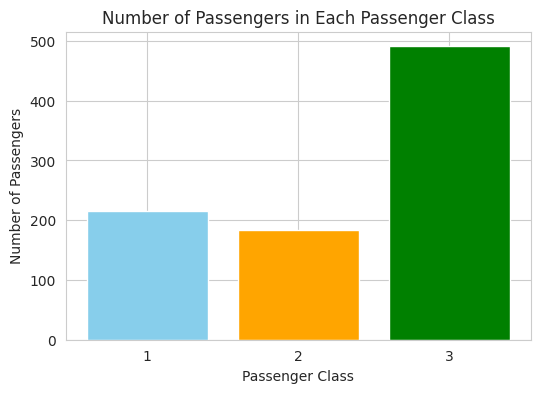

,count
Pclass,
1,216
2,184
3,491


In [10]:
class_counts = df["Pclass"].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(class_counts.index.astype(str), class_counts.values, color=["skyblue", "orange", "green"])
plt.title("Number of Passengers in Each Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.show()

class_counts

Interpretation: Passenger class 3 has the highest number of passengers, followed by class 1 and class 2.

Q3. Create a histogram to show the distribution of passenger age.

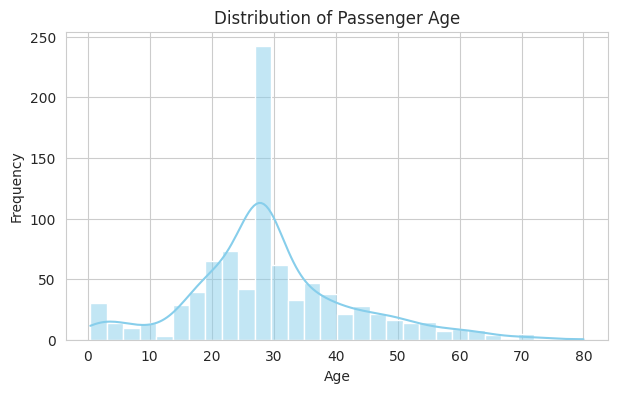

,Age
count,891.000000
mean,29.361582
std,13.019697
min,0.420000
25%,22.000000
50%,28.000000
75%,35.000000
max,80.000000


In [11]:
plt.figure(figsize=(7,4))
sns.histplot(df["Age"], bins=30, kde=True, color="skyblue")
plt.title("Distribution of Passenger Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

df["Age"].describe()

Interpretation: Most passengers are in the young to middle-age group. Very few passengers are at very low or very high ages.

Q4. Create a boxplot to detect outliers in the fare column.

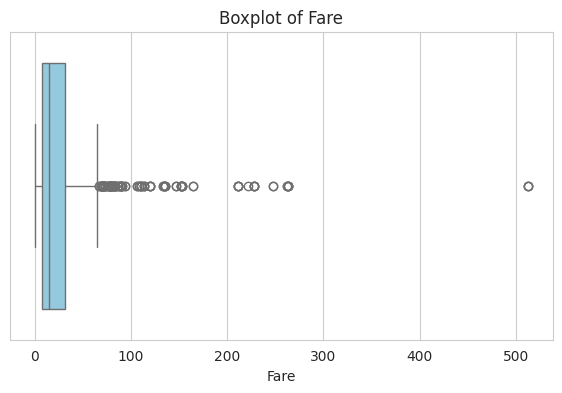

,Fare
count,891.000000
mean,32.204208
std,49.693429
min,0.000000
25%,7.910400
50%,14.454200
75%,31.000000
max,512.329200


In [12]:
plt.figure(figsize=(7,4))
sns.boxplot(x=df["Fare"], color="skyblue")
plt.title("Boxplot of Fare")
plt.xlabel("Fare")
plt.show()

df["Fare"].describe()

Interpretation: The fare column has many high-value outliers. Most fares are in the lower range, but some passengers paid much higher fares.

Q5. Create a scatterplot to  
 a. show the relationship between age and fare.  
 b. analyze the relationship between family size (SibSp + Parch) and fare.

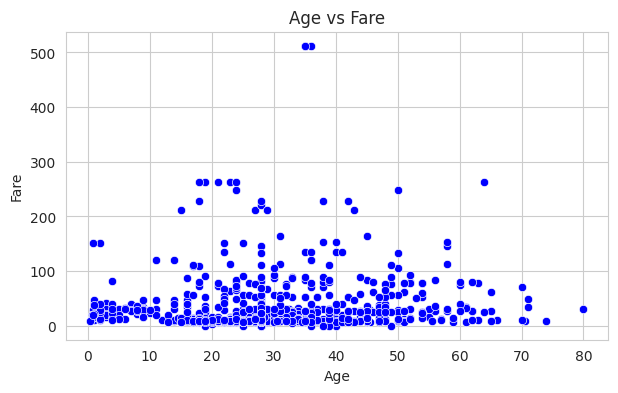

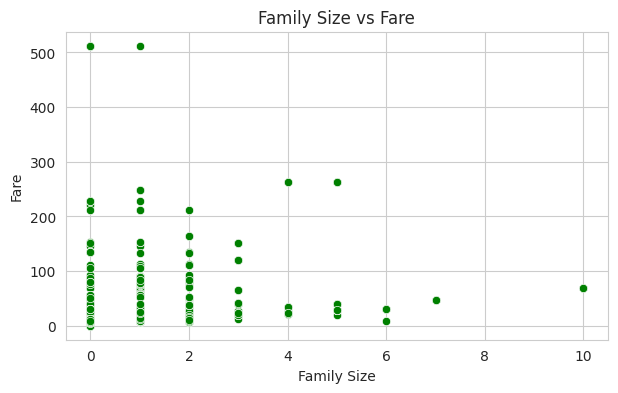

Correlation between Age and Fare: 0.09668842218036484
Correlation between Family Size and Fare: 0.2171384070524334


In [13]:
df["FamilySize"] = df["SibSp"] + df["Parch"]

plt.figure(figsize=(7,4))
sns.scatterplot(x="Age", y="Fare", data=df, color="blue")
plt.title("Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

plt.figure(figsize=(7,4))
sns.scatterplot(x="FamilySize", y="Fare", data=df, color="green")
plt.title("Family Size vs Fare")
plt.xlabel("Family Size")
plt.ylabel("Fare")
plt.show()

print("Correlation between Age and Fare:", df["Age"].corr(df["Fare"]))
print("Correlation between Family Size and Fare:", df["FamilySize"].corr(df["Fare"]))

Interpretation: Age and fare have a very weak relationship. Family size and fare show a small positive relationship, which means fare slightly increases as family size increases.

Q6. Create a countplot to show survival count by gender.

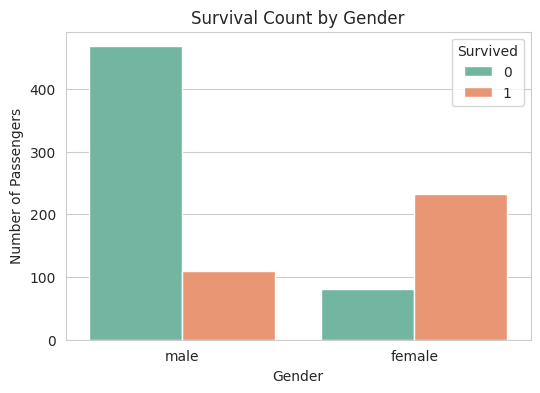

Survived,0,1
Sex,,
female,81,233
male,468,109


In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x="Sex", hue="Survived", data=df, palette="Set2")
plt.title("Survival Count by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.show()

pd.crosstab(df["Sex"], df["Survived"])

Interpretation: Female passengers survived more than male passengers. Male passengers have a higher death count.

Q7. Create a bar chart to show survival by passenger class.

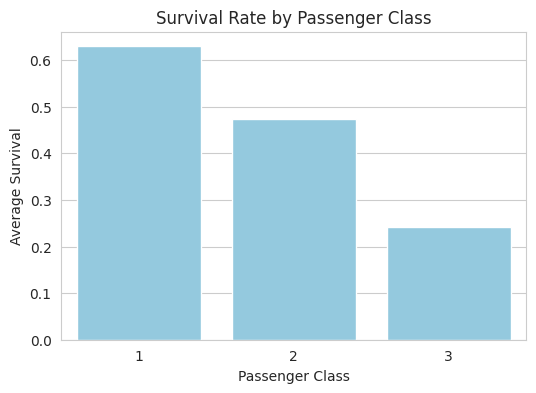

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


In [15]:
survival_by_class = df.groupby("Pclass")["Survived"].mean()

plt.figure(figsize=(6,4))
sns.barplot(x=survival_by_class.index, y=survival_by_class.values, color="skyblue")
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Average Survival")
plt.show()

survival_by_class

Interpretation: First class passengers have the highest survival rate. Third class passengers have the lowest survival rate.

Q8. Create a heatmap to show correlation between numerical variables.

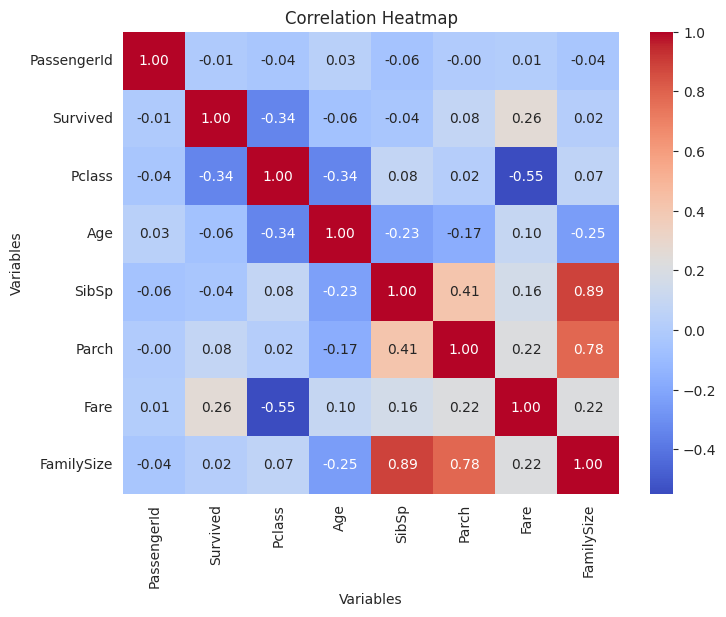

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize
PassengerId,1.000000,-0.005007,-0.035144,0.034212,-0.057527,-0.001652,0.012658,-0.040143
Survived,-0.005007,1.000000,-0.338481,-0.064910,-0.035322,0.081629,0.257307,0.016639
Pclass,-0.035144,-0.338481,1.000000,-0.339898,0.083081,0.018443,-0.549500,0.065997
Age,0.034212,-0.064910,-0.339898,1.000000,-0.233296,-0.172482,0.096688,-0.245619
SibSp,-0.057527,-0.035322,0.083081,-0.233296,1.000000,0.414838,0.159651,0.890712
Parch,-0.001652,0.081629,0.018443,-0.172482,0.414838,1.000000,0.216225,0.783111
Fare,0.012658,0.257307,-0.549500,0.096688,0.159651,0.216225,1.000000,0.217138
FamilySize,-0.040143,0.016639,0.065997,-0.245619,0.890712,0.783111,0.217138,1.000000


In [16]:
numerical_df = df.select_dtypes(include=np.number)
correlation_matrix = numerical_df.corr()

plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.xlabel("Variables")
plt.ylabel("Variables")
plt.show()

correlation_matrix

Interpretation: Fare and survival have a positive relationship. Passenger class and survival have a negative relationship, which means lower class number is linked with higher survival.

Q9. Identify which passenger class paid the highest fare on average.

In [17]:
avg_fare_by_class = df.groupby("Pclass")["Fare"].mean().sort_values(ascending=False)
avg_fare_by_class

,Fare
Pclass,
1,84.154687
2,20.662183
3,13.675550


Interpretation: Passenger class 1 paid the highest fare on average.

Q10. Write at least 5 insights from the dataset based on your visualizations.

In [18]:
insights = [
    "1. Male passengers are more than female passengers in the dataset.",
    "2. Most passengers belong to passenger class 3.",
    "3. Passenger ages are mostly concentrated in the young to middle-age range.",
    "4. The fare column has many outliers, and a small number of passengers paid very high fares.",
    "5. Female passengers survived more than male passengers.",
    "6. First class passengers had a better survival rate than second and third class passengers.",
    "7. Passenger class 1 paid the highest fare on average.",
    "8. Age has only a weak relationship with fare."
]

for insight in insights:
    print(insight)

1. Male passengers are more than female passengers in the dataset.
2. Most passengers belong to passenger class 3.
3. Passenger ages are mostly concentrated in the young to middle-age range.
4. The fare column has many outliers, and a small number of passengers paid very high fares.
5. Female passengers survived more than male passengers.
6. First class passengers had a better survival rate than second and third class passengers.
7. Passenger class 1 paid the highest fare on average.
8. Age has only a weak relationship with fare.
